# Analysis of the Strogatz problems

## Prelude

In [1]:
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sympy

import AnalysisUtils as au

## Loading data

These are the results of Jessamine symbolic regression.

In [3]:
full_report = pd.read_csv("For-analysis/full-report.csv")

In [4]:
full_report["sympy"] = full_report.expr_original_syms.apply(au.parse_if_needed)
full_report["sympy_defuzz"] = full_report.expr_original_syms_defuzz.apply(au.parse_if_needed)

In [5]:
full_report.sort_values(["run_set", "data_set", "mse"], inplace=True)
fr2 = full_report.set_index(["run_set", "data_set", "sample_num"])

In [6]:
full_report.run_set.unique()

<StringArray>
['CHT-2026-07-13-1130', 'SRB-2026-07-13-1130', 'SRB-2026-07-25-1900']
Length: 3, dtype: str

In [7]:
srb_key = "SRB-2026-07-13-1130"
cht_key = "CHT-2026-07-13-1130"
srb = fr2.loc[srb_key]
cht = fr2.loc[cht_key]

These are the best ones overall

In [8]:
srb_min_mse_ixs = srb.groupby(level=["data_set"]).mse.idxmin()
cht_min_mse_ixs = cht.groupby(level=["data_set"]).mse.idxmin()

In [9]:
srb.loc[srb_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_bacres1,13,6.676241e-10,25,-0.99997238476261*x - 4.00053992354429*y/(2*x ...
d_bacres2,30,1.642565e-23,23,10 - 2*y/x - 8*y/(x*(-2*x**2 - 4))
d_barmag1,22,1.083862e-28,13,-sin(x) + 0.499999999999982*sin(x - y)
d_barmag2,23,7.117569e-29,13,-sin(y) - 0.499999999999968*sin(x - y)
d_glider1,3,2.751114e-28,10,-0.05*x**2 - sin(y)
d_glider2,14,3.850344e-28,9,x - cos(y)/x
d_lv1,9,2.062307e-29,14,-2*x*y + x - (x - 1)**2 + 1
d_lv2,31,2.030504e-29,13,-x*y - (y - 1)**2 + 1
d_predprey1,31,6.018009e-28,19,-x**2 + 4*x - y + y/(x + 1)


In [10]:
cht.loc[cht_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_bacres1,14,9.446943e-26,17,-x - 2*y/(x + 2/x) + 20
d_bacres2,21,8.139628e-23,21,10 - 2*y/x + 4*y/(x*(x**2 + 2))
d_barmag1,2,1.485169e-28,13,-sin(x) + 0.499999999999967*sin(x - y)
d_barmag2,10,1.319518e-28,13,-sin(y) - 0.499999999999973*sin(x - y)
d_glider1,8,2.751114e-28,10,-0.05*x**2 - sin(y)
d_glider2,3,3.682481e-28,20,x - 0.465974900447998*sin(y + 0.00833333333333...
d_lv1,15,2.922714e-29,14,-2*x*y + x - (x - 1)**2 + 1
d_lv2,8,2.488675e-29,15,-x*y - 0.25*(2 - 2*y)**2 + 1
d_predprey1,31,1.880879e-25,22,-x**2 + 4*x - y + 4*y/(4*x + 4)


In [11]:
main_data_sets = list(fr2.index.get_level_values("data_set").unique())
main_data_sets.remove("d_sfgrid1")
main_data_sets.remove("d_sfgrid2")
main_data_sets

['d_bacres1',
 'd_bacres2',
 'd_barmag1',
 'd_barmag2',
 'd_glider1',
 'd_glider2',
 'd_lv1',
 'd_lv2',
 'd_predprey1',
 'd_predprey2',
 'd_shearflow1',
 'd_shearflow2',
 'd_vdp1',
 'd_vdp2']

In [12]:
fr3 = fr2.loc[fr2.index.isin(main_data_sets, level="data_set")]

In [13]:
srb_threshold_table = au.mse_threshold_table(srb)
srb_threshold_table

,mse_min,mse_med,mse_max,mse00,mse04,mse08,mse12,mse16,mse20,mse24,mse28,mse32
data_set,,,,,,,,,,,,
d_bacres1,6.676241e-10,4.766770e-08,2.398851e-07,32,32,6,0,0,0,0,0,0
d_bacres2,1.642565e-23,1.546969e-08,2.133374e-07,32,32,14,1,1,1,0,0,0
d_barmag1,1.083862e-28,1.547256e-28,2.180075e-28,32,32,32,32,32,32,32,0,0
d_barmag2,7.117569e-29,1.340650e-28,2.294829e-28,32,32,32,32,32,32,32,1,0
d_glider1,2.751114e-28,2.752178e-28,2.758214e-28,32,32,32,32,32,32,32,0,0
d_glider2,3.850344e-28,4.299482e-28,7.001978e-27,32,32,32,32,32,32,32,0,0
d_lv1,2.062307e-29,3.254316e-28,5.393771e-27,32,32,32,32,32,32,32,3,0
d_lv2,2.030504e-29,1.084850e-28,2.180769e-27,32,32,32,32,32,32,32,13,0
d_predprey1,6.018009e-28,4.753500e-06,6.064031e-04,32,25,11,5,5,5,3,0,0


In [14]:
srb_threshold_table.to_csv("Generated/srb_threshold_table.csv")
au.to_latex(
    srb_threshold_table,
    file="Generated/srb_threshold_table.tex",
    strip_colname_prefix="mse",
    strip_rowname_prefix="d_",
)

In [15]:
cht_threshold_table = au.mse_threshold_table(cht)
cht_threshold_table

,mse_min,mse_med,mse_max,mse00,mse04,mse08,mse12,mse16,mse20,mse24,mse28,mse32
data_set,,,,,,,,,,,,
d_bacres1,9.446943e-26,3.226673e-09,2.145363e-08,32,32,29,1,1,1,1,0,0
d_bacres2,8.139628e-23,1.555213e-09,1.918174e-08,32,32,30,1,1,1,0,0,0
d_barmag1,1.485169e-28,1.549745e-28,2.225098e-28,32,32,32,32,32,32,32,0,0
d_barmag2,1.319518e-28,1.383502e-28,2.241397e-28,32,32,32,32,32,32,32,0,0
d_glider1,2.751114e-28,2.752594e-28,2.758214e-28,32,32,32,32,32,32,32,0,0
d_glider2,3.682481e-28,4.232594e-28,1.425206e-27,32,32,32,32,32,32,32,0,0
d_lv1,2.922714e-29,4.080127e-28,2.004553e-24,32,32,32,32,32,32,31,2,0
d_lv2,2.488675e-29,1.079174e-28,9.170154e-23,32,32,32,32,32,32,31,14,0
d_predprey1,1.880879e-25,1.957373e-08,1.214128e-03,32,21,16,3,3,3,1,0,0


In [16]:
cht_threshold_table.to_csv("Generated/cht_threshold_table.csv")
au.to_latex(
    cht_threshold_table,
    file="Generated/cht_threshold_table.tex",
    strip_colname_prefix="mse",
    strip_rowname_prefix="d_",
)

These are problems I ran extra samples of to get better reliability estimates.

In [17]:
srb_extra_key = "SRB-2026-07-25-1900"
extra_problems = ["d_bacres1", "d_bacres2", "d_shearflow1"]
srb_extra = fr2.loc[([srb_key, srb_extra_key], extra_problems),:]

In [18]:
srb_extra.sort_values("mse", ascending=True).head()

rating           mse  \
run_set             data_set  sample_num                               
SRB-2026-07-25-1900 d_bacres2 118         1.610000e-10  1.727775e-25   
                              68          7.702983e-11  2.149504e-24   
SRB-2026-07-13-1130 d_bacres2 30          1.270391e-10  1.642565e-23   
SRB-2026-07-25-1900 d_bacres2 30          1.270391e-10  1.642565e-23   
                              151         3.404611e-10  1.379488e-13   

                                          complexity  complexity_defuzz  \
run_set             data_set  sample_num                                  
SRB-2026-07-25-1900 d_bacres2 118                104                 13   
                              68                  59                 21   
SRB-2026-07-13-1130 d_bacres2 30                  31                 23   
SRB-2026-07-25-1900 d_bacres2 30                  31                 23   
                              151                 48                 31   

                                                                                       expr  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118         8.484103979861607e-20*x1**3*(-x1 + cos(2*x1**2...   
                              68          9.064467968949157e-17*sqrt(x1) - 1.22066465794...   
SRB-2026-07-13-1130 d_bacres2 30          8.240913964575768e-14*x1**2 - 1.73420607236174...   
SRB-2026-07-25-1900 d_bacres2 30          8.240913964575768e-14*x1**2 - 1.73420607236174...   
                              151         -2.7722578996303149e-8*x1**2 + 8.6288945017054...   

                                                                                expr_defuzz  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118                                 -2*x1*x2/(x1**2 + 2) + 10   
                              68                       10 - 2*x2/x1 + 4*x2/(x1*(x1**2 + 2))   
SRB-2026-07-13-1130 d_bacres2 30                    10 - 2*x2/x1 - 8*x2/(x1*(-2*x1**2 - 4))   
SRB-2026-07-25-1900 d_bacres2 30                    10 - 2*x2/x1 - 8*x2/(x1*(-2*x1**2 - 4))   
                              151         10.0005109415404 - 2*x2/x1 + 4.00017475576856*...   

                                                                         expr_original_syms  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118         8.484103979861607e-20*x**3*(-x + cos(2*x**2 - ...   
                              68          9.064467968949157e-17*sqrt(x) - 1.220664657947...   
SRB-2026-07-13-1130 d_bacres2 30          8.240913964575768e-14*x**2 - 1.73420607236174e...   
SRB-2026-07-25-1900 d_bacres2 30          8.240913964575768e-14*x**2 - 1.73420607236174e...   
                              151         -2.7722578996303149e-8*x**2 + 8.62889450170545...   

                                                                  expr_original_syms_defuzz  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118                                    -2*x*y/(x**2 + 2) + 10   
                              68                            10 - 2*y/x + 4*y/(x*(x**2 + 2))   
SRB-2026-07-13-1130 d_bacres2 30                         10 - 2*y/x - 8*y/(x*(-2*x**2 - 4))   
SRB-2026-07-25-1900 d_bacres2 30                         10 - 2*y/x - 8*y/(x*(-2*x**2 - 4))   
                              151         10.0005109415404 - 2*y/x + 4.00017475576856*y/...   

                                                                                      sympy  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118         8.484103979861607e-20*x**3*(-x + cos(2*x**2 - ...   
                              68          9.064467968949157e-17*sqrt

## Polynomials

In [19]:
data_sets_polynomial = [
    "d_lv1",
    "d_lv2",
    "d_vdp1",
    "d_vdp2"
    ]

In [20]:
srb.loc[data_sets_polynomial]

rating           mse  complexity  \
data_set sample_num                                           
d_lv1    9           1.158486e-11  2.062307e-29          16   
         6           1.834465e-11  3.460740e-29          18   
         12          1.006258e-11  6.346817e-29          16   
         20          1.402424e-11  1.238791e-28          18   
         5           7.019290e-12  2.054727e-28          14   
...                           ...           ...         ...   
d_vdp2   24          1.010000e-12  7.733000e-32           5   
         27          1.010000e-12  7.733000e-32           5   
         30          1.010000e-12  7.733000e-32           5   
         31          1.010000e-12  7.733000e-32           5   
         17          1.010000e-12  7.931422e-32           5   

                     complexity_defuzz  \
data_set sample_num                      
d_lv1    9                          14   
         6                          18   
         12                         14   
         20                         16   
         5                          13   
...                                ...   
d_vdp2   24                          3   
         27                          3   
         30                          3   
         31                          3   
         17                          3   

                                                                  expr  \
data_set sample_num                                                      
d_lv1    9           -2.0*x1*x2 + 1.0000000000000009*x1 - 1.0*(x1 -...   
         6           -1.9999999999999956*x1*x2 + 0.9500000000000025...   
         12          2.9999999999999964*x1 + 0.9999999999999978*x2*...   
         20          -1.9999999999999913*x1*x2 + 1.000000000000001*...   
         5           -1.000000000000003*x1**2 - 1.9999999999999964*...   
...                                                                ...   
d_vdp2   24             -0.0999999999999997*x1 - 1.510668920681427e-16   
         27           -0.09999999999999969*x1 - 1.5106689206814288e-16   
         30            -0.09999999999999969*x1 - 1.510668920681428e-16   
         31            -0.09999999999999969*x1 - 1.510668920681428e-16   
         17           -0.09999999999999967*x1 - 2.0488826271266727e-16   

                                                           expr_defuzz  \
data_set sample_num                                                      
d_lv1    9                             -2*x1*x2 + x1 - (x1 - 1)**2 + 1   
         6           -2*x1*x2 + 0.950000000000003*x1 - (1.025 - x1)...   
         12                                3*x1 + x2**2 - (x1 + x2)**2   
         20                            -2*x1*x2 + x1 - (1 - x1)**2 + 1   
         5                                     -x1**2 - 2*x1*x2 + 3*x1   
...                                                                ...   
d_vdp2   24                                     -0.0999999999999997*x1   
         27                                     -0.0999999999999997*x1   
         30                                     -0.0999999999999997*x1   
         31                                     -0.0999999999999997*x1   
         17                                     -0.0999999999999997*x1   

                                                    expr_original_syms  \
data_set sample_num                                                      
d_lv1    9           -2.0*x*y + 1.0000000000000009*x - 1.0*(x - 1)*...   
         6           -1.9999999999999956*x*y + 0.9500000000000025*x...   
         12          2.9999999999999964*x + 0.9999999999999978*y**2...   
         20          -1.9999999999999913*x*y + 1.000000000000001*x ...   
         5           -1.000000000000003*x**2 - 1.9999999999999964*x...   
...                                                                ...   
d_vdp2   24              -0.0999999999999997*x - 1.510668920681427e-16   
         27            -0.09999999999999969*x - 1.5106689206814288e-

The best ones are exactly correct.

In [21]:
srb.loc[srb_min_mse_ixs].loc[data_sets_polynomial, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_lv1,9,2.062307e-29,14,-2*x*y + x - (x - 1)**2 + 1
d_lv2,31,2.030504e-29,13,-x*y - (y - 1)**2 + 1
d_vdp1,3,6.566827e-28,12,-3.33333333333333*x**3 + 3.33333333333333*x + ...
d_vdp2,10,4.865352e-32,3,-0.0999999999999998*x


In [22]:
srb.loc[data_sets_polynomial, "sympy"].apply(lambda x: au.replace_near_integer(sympy.expand(x), tolerance=1e-10))

data_set  sample_num
d_lv1     9                -x**2 - 2*x*y + 3*x
          6                -x**2 - 2*x*y + 3*x
          12               -x**2 - 2*x*y + 3*x
          20               -x**2 - 2*x*y + 3*x
          5                -x**2 - 2*x*y + 3*x
                                 ...          
d_vdp2    24             -0.0999999999999997*x
          27            -0.09999999999999969*x
          30            -0.09999999999999969*x
          31            -0.09999999999999969*x
          17            -0.09999999999999967*x
Name: sympy, Length: 128, dtype: object

Apart from fuzz, each result is a polynomial in $x$ and $y$.

In [23]:
(srb.loc[data_sets_polynomial]
 .sympy_defuzz.apply(lambda e: not e.is_polynomial(sympy.abc.x, sympy.abc.y))
 .groupby(level="data_set")
 .sum())

data_set
d_lv1     0
d_lv2     0
d_vdp1    0
d_vdp2    0
Name: sympy_defuzz, dtype: int64

All runs on all polynomial data sets are correct up to fuzz.

In [24]:
au.count_by_threshold(srb.loc[data_sets_polynomial])

data_set
d_lv1     32
d_lv2     32
d_vdp1    32
d_vdp2    32
Name: mse, dtype: int64

In [25]:
polynomial_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 29),
    "complexity_binwidth": 1,
    "mse_lims": (1.0e-32, 1.2e-20),
    "mse_binwidth": 0.5,
    "spiffy_titles": [r"Lotka-Volterra $x$", r"Lotka-Volterra $y$", r"Van der Pol $x$", r"Van der Pol $y$"],
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

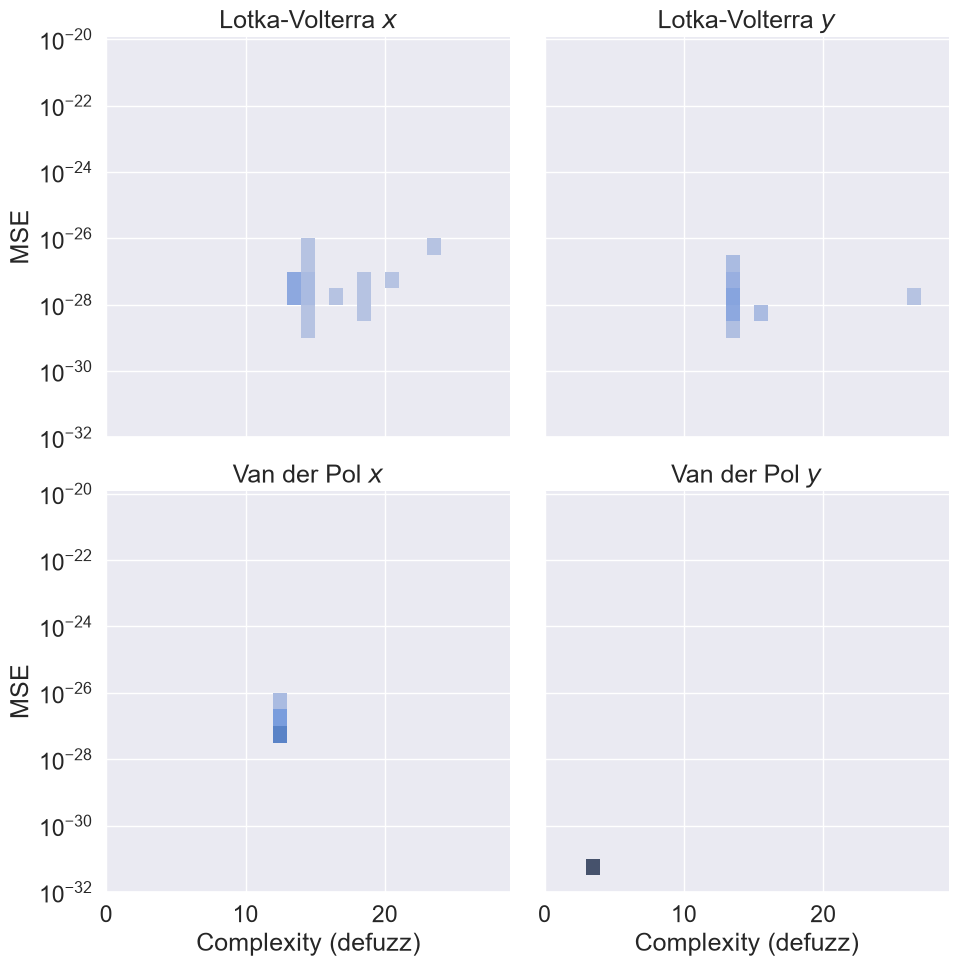

In [26]:
au.complexity_mse_displot(
    srb.loc[data_sets_polynomial],
    file_stem="srb-polynomial-complexity-mse-displot",
    **polynomial_plot_params
    )

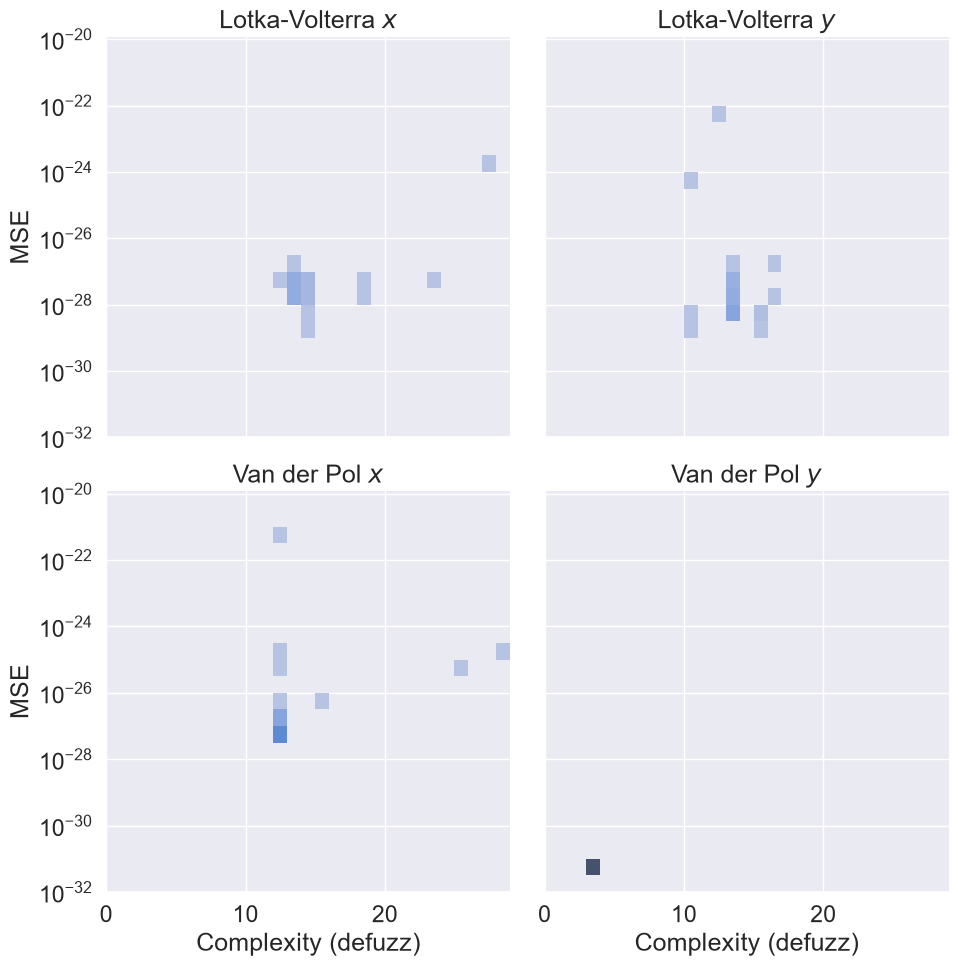

In [27]:
au.complexity_mse_displot(
    cht.loc[data_sets_polynomial],
    file_stem="cht-polynomial-complexity-mse-displot",
    **polynomial_plot_params
    )

## Rational functions

In [28]:
data_sets_rational = [
    "d_bacres1",
    "d_bacres2",
    "d_predprey1",
    "d_predprey2"
    ]

In [29]:
srb.loc[srb_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_bacres1,13,6.676241e-10,25,-0.99997238476261*x - 4.00053992354429*y/(2*x ...
d_bacres2,30,1.642565e-23,23,10 - 2*y/x - 8*y/(x*(-2*x**2 - 4))
d_predprey1,31,6.018009e-28,19,-x**2 + 4*x - y + y/(x + 1)
d_predprey2,12,1.321588e-27,22,1.07499999999993*y - y/(x + 1) - 0.01874999999...


The majority of solutions are not rational functions.
Most of them are actually fine apart from fuzz and cruft.

In [30]:
(srb.loc[data_sets_rational]
 .sympy_defuzz
 .apply(lambda e: not e.is_rational_function())
 .groupby(level="data_set").sum())

data_set
d_bacres1      24
d_bacres2      19
d_predprey1    22
d_predprey2    26
Name: sympy_defuzz, dtype: int64

### Predator-prey

In [31]:
srb.loc["d_predprey1", ["mse", "complexity_defuzz", "sympy_defuzz", "sympy"]]

,mse,complexity_defuzz,sympy_defuzz,sympy
sample_num,,,,
31,6.018009e-28,19,-x**2 + 4*x - y + y/(x + 1),-0.9999999999999952*x**2 + 3.999999999999998*x...
15,9.629533e-28,36,-0.444444444444444*x**2 + 4.66666666666662*x -...,-0.44444444444444376*x**2 + 4.6666666666666183...
22,1.198757e-27,19,-x**2 + 4*x - y + y/(x + 1),-1.2429192344000993e-17*x**6 - 0.9999999999999...
3,1.842078e-23,30,-x**2 + 4*x - y - y/(2*x + 2) + 1.499999999950...,-1.0000000000014848*x**2 + 4.000000000000256*x...
26,2.664672e-23,24,2.31705803037141*x - y + y/(x + 1) - (0.841470...,2.3170580303714095*x - 0.9999999999882593*y + ...
5,2.769151e-10,48,-1.00003345414783*x**2 + 2.52684648756615e-5*x...,-1.000033454147831*x**2 + 2.5268464875661474e-...
13,4.935665e-10,28,-1.00002314439355*x*(x + 1.00009508103197) + 5...,1.783975632983218e-6*x*y*(x + 1.00009508103197...
32,1.391309e-09,28,5.99512401726396*x - 0.999970822493829*y - 0.9...,5.9951240172639577*x - 0.9999708224938288*y - ...
20,1.536741e-09,79,-2.24483694134812e-5*x*(x + (x + 1.99928178698...,-2.2448369413481222e-5*x*(x + (x + 1.999281786...


In [32]:
srb.loc["d_predprey1"].sympy.apply(lambda x: au.replace_near_integer(sympy.expand(x), tolerance=1e-10))

sample_num
31                          -x**2 + 4*x - y + y/(x + 1)
15                          -x**2 + 4*x - y + y/(x + 1)
22                          -x**2 + 4*x - y + y/(x + 1)
3     -x**2 + 4*x - y - y/(2*x + 2) + 1.499999999950...
26                          -x**2 + 4*x - y + y/(x + 1)
5     -1.000033454147831*x**2 + 2.5268464875661474e-...
13    1.247416209281751e-10*x**4*y**2 - 1.6516208036...
32    -1.2023508765078236e-6*x**4 - 7.20981939654006...
20    -2.2448369413481222e-5*x**4 + 0.00051452447291...
19    -1.0000568026490681*x**2 + 4.0010724360081581*...
17    1.4735312813927842e-8*x**6 - 4.420593844178352...
12    -1.000304781831962*x**2 + 4.0006281134177305*x...
27    -0.0072413272549818333*x**3 - 2.53795379024384...
9     -6.732720100692585e-5*x**4 + 0.000856715658261...
21    -0.0008408123171719787*x**3 - 0.99077111266076...
11    4.0395726396780116*x - 1.00053382216395*y + 2....
28    -1.005328244740005*x**2 + 4.011507832464815*x ...
16    -0.0006660933199160777*x**3 - 0

In [33]:
srb.loc["d_predprey1"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-4))

sample_num
31                          -x**2 + 4*x - y + y/(x + 1)
15                          -x**2 + 4*x - y + y/(x + 1)
22                          -x**2 + 4*x - y + y/(x + 1)
3     -x**2 + 4*x - y - y/(2*x + 2) + 1.499999999950...
26                          -x**2 + 4*x - y + y/(x + 1)
5     -x**2 + 4*x - 1.000116945231131*y + 4*y/(3.999...
13    -x**2 + 4.0001103292912493*x - y + 1.000150090...
32    -0.99980497322810531*x**2 + 3.9990949387423711...
20    0.00051452447291130339*x**3 - 1.00529677211979...
19    -x**2 + 4.0010724360081581*x - 0.0022697325786...
17    -1.000188470523606*x**2 - 1.000188470523606*x*...
12    -1.000304781831962*x**2 + 4.0006281134177305*x...
27    -0.0072413272549818333*x**3 - 2.53795379024384...
9     0.0008567156582619106*x**3 + 0.000315850429905...
21    -0.0008408123171719787*x**3 - 0.99077111266076...
11    4.0395726396780116*x - 1.00053382216395*y + 2....
28    -1.005328244740005*x**2 + 4.011507832464815*x ...
16    -0.0006660933199160777*x**3 - 0

The predator-prey problem is well-behaved.
There are solution at MSE $8\times 10^{-9}$ and $1.9\times 10^{-8}$ with an imperfect denominator that's pretty close, so I'll use $2\times 10^{-8}$ as a cutoff.

In [34]:
rational_threshold = 2.0e-8

In [35]:
srb.loc["d_predprey2", ["mse", "complexity_defuzz", "sympy_defuzz"]]

,mse,complexity_defuzz,sympy_defuzz
sample_num,,,
12,1.321588e-27,22,1.07499999999993*y - y/(x + 1) - 0.01874999999...
4,2.881930e-27,15,-0.0749999999999903*y**2 + y - y/(x + 1)
1,4.621458e-27,15,-0.0750000000000116*y**2 + y - y/(x + 1)
14,2.861432e-10,20,-2.72407564507011e-5*x - 0.0750008905880003*y*...
23,1.231130e-09,34,-4.19353466196712e-5*x + 0.000539522518368261*...
19,1.956808e-09,40,-0.000338354076596964*x + 1.0858368906816*y + ...
17,2.297817e-09,29,9.01643988067957e-5*x - 0.0750215397840049*y**...
29,2.686152e-09,25,-0.000654606615192909*x + 0.850130018834741*y ...
25,4.594998e-09,39,-0.000454890335631613*x + 13.4215832707214*y +...


In [36]:
srb.loc["d_predprey2"].sympy.apply(lambda x: au.replace_near_integer(sympy.expand(x), tolerance=1e-10))

sample_num
12           -0.074999999999995376*y**2 + y - y/(x + 1)
4             -0.07499999999999027*y**2 + y - y/(x + 1)
1            -0.074999999999996195*y**2 + y - y/(x + 1)
14    -2.7240756450701121e-5*x - 0.07500089058800033...
23    -4.1935346619671168e-5*x - 0.07499928111543761...
19    -4.7697756370659692e-10*x**(15/2) - 9.15175777...
17    1.498764666320722e-6*x**3 + 2.3937635703692279...
29    -1.7562488001076659e-5*x**3 + 0.00017975774882...
25    -0.00045489033563161293*x + 9.671623484986644e...
24    4.571598057164313e-7*x**5 + 9.143196114328626e...
18    -0.07503014722301501*y**2 + 1.0007397904470323...
10    -5.5005078024000786e-5*x - 6.206941918893644e-...
26    -4.5947311082180903e-6*x**2*y**2 - 0.000342317...
20    -0.0005866609401013977*x**3 - 0.00208737362957...
2     -0.08667441653623452*x - 0.07503301920915121*y...
15    -0.4500956419429719*x*y*exp(-x) + 0.1958861389...
27    -0.00145396492657564*x**3 + 0.0122508031816293...
6     -0.0004926214651529086*x**3 - 9

In [37]:
srb.loc["d_predprey2"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=2.0e-3))

sample_num
12           -0.074999999999995376*y**2 + y - y/(x + 1)
4             -0.07499999999999027*y**2 + y - y/(x + 1)
1            -0.074999999999996195*y**2 + y - y/(x + 1)
14            -0.07500089058800033*y**2 + y - y/(x + 1)
23           -0.074999281115437611*y**2 + y - y/(x + 1)
19           -0.07500267020666095*y**2 + y + y/(-x - 1)
17             -0.0750215397840049*y**2 + y - y/(x + 1)
29        -0.07500188776215418*y**2 + y - 4*y/(4*x + 4)
25    -0.0749810641710319*y**2 + y - y/(x + 1) + 0.0...
24    0.4997777541243372*x*y/(x + 1) - 0.07499455075...
18    -0.07503014722301501*y**2 + y - 0.002272638124...
10    -0.07349555296673008*y**2 + 0.9877739729538461...
26    -0.0043068794100755061*x**2 + 1.30857161493788...
20    -0.002087373629574956*x**3*exp(-x) - 0.0024756...
2     -0.08667441653623452*x - 0.07503301920915121*y...
15    -0.4500956419429719*x*y*exp(-x) + 0.1958861389...
27    0.01225080318162931*x**2*sqrt(y) - 0.004361894...
6     -0.07187791132652607*y**2 + 1.0

In [38]:
au.count_by_threshold(srb.loc[data_sets_rational], threshold=rational_threshold)

data_set
d_bacres1      11
d_bacres2      17
d_predprey1    12
d_predprey2    11
Name: mse, dtype: int64

In [39]:
predprey1_ex_A = srb.loc[("d_predprey1", 17), "sympy"]
predprey1_ex_A

1.4735312813927842e-8*x**3*(x + sin((x + 2.6320191573903093)*sin(x - 2*y)) - sin(x - 2*y))**3 + 4.000666681322522*x + 1.000558067353919*y/(x + 1.0001347562661234) - 0.2500471176309015*(-2*x - y + 1.0001081419449563*Abs(y) - 0.00021629558459279608)**2 - 9.852896645761433e-6*sin((x + 2.6320191573903093)*sin(x - 2*y)) + 9.852896645761433e-6*sin(x - 2*y) + 1.4735312813927842e-8*cos(y + y/(x + 1.0001347562661234)) - 1.0003901672974322*Abs(y) - 0.0001090277665742774

In [40]:
predprey1_ex_A = srb.loc[("d_predprey1", 17), "sympy"]
predprey1_ex_A

1.4735312813927842e-8*x**3*(x + sin((x + 2.6320191573903093)*sin(x - 2*y)) - sin(x - 2*y))**3 + 4.000666681322522*x + 1.000558067353919*y/(x + 1.0001347562661234) - 0.2500471176309015*(-2*x - y + 1.0001081419449563*Abs(y) - 0.00021629558459279608)**2 - 9.852896645761433e-6*sin((x + 2.6320191573903093)*sin(x - 2*y)) + 9.852896645761433e-6*sin(x - 2*y) + 1.4735312813927842e-8*cos(y + y/(x + 1.0001347562661234)) - 1.0003901672974322*Abs(y) - 0.0001090277665742774

In [41]:
print(sympy.latex(predprey1_ex_A))

1.4735312813927842 \cdot 10^{-8} x^{3} \left(x + \sin{\left(\left(x + 2.6320191573903093\right) \sin{\left(x - 2 y \right)} \right)} - \sin{\left(x - 2 y \right)}\right)^{3} + 4.000666681322522 x + \frac{1.000558067353919 y}{x + 1.0001347562661234} - 0.2500471176309015 \left(- 2 x - y + 1.0001081419449563 \left|{y}\right| - 0.00021629558459279608\right)^{2} - 9.852896645761433 \cdot 10^{-6} \sin{\left(\left(x + 2.6320191573903093\right) \sin{\left(x - 2 y \right)} \right)} + 9.852896645761433 \cdot 10^{-6} \sin{\left(x - 2 y \right)} + 1.4735312813927842 \cdot 10^{-8} \cos{\left(y + \frac{y}{x + 1.0001347562661234} \right)} - 1.0003901672974322 \left|{y}\right| - 0.0001090277665742774


In [42]:
predprey1_ex_A_pos = sympy.posify(au.replace_near_integer(predprey1_ex_A.evalf(), tolerance=1.0e-3))
predprey1_ex_A_pos[0]

-1.00018847052361*_x**2 + 4*_x - _y + _y/(_x + 1)

In [43]:
predprey1_ex_B = srb.loc[("d_predprey1", 12), "sympy"]
predprey1_ex_B

-1.000304781831962*x**2 + 4.0006281134177305*x - 1.3174337704484707e-5*y**2 - 0.9837859661603241*y + 0.9683765198931952*y/(0.01700183997085254*x**2 + x + 0.9842015645998924) - 0.0003693992992487927

In [44]:
au.replace_near_integer(predprey1_ex_B.evalf(), tolerance=2.0e-2)

-x**2 + 4*x - y + 0.968376519893195*y/(x + 1)

### Bacterial respiration

These problems aren't so well behaved.

In [45]:
srb.loc["d_bacres1"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-10))

sample_num
13    -0.99997238476260994*x - 4.000539923544289*y/(...
23    -1.0427523359980421e-7*x*y**2 - 3.241789920372...
18    -0.044807114097848474*sqrt(x) - 0.994940771260...
21    -7.573180264063094e-7*x**3 + 1.463691704632104...
5     -1.7583802634605219e-6*x**3 - 2.24513782603324...
10    -0.99111347545339279*x - 0.0002006152407831801...
29    4.839657478492173e-9*x**2*y**2 - 2.90379448709...
11    8.351960059911586e-10*x**6 + 3.312852089471179...
8     -22.942394411590324*y*sin(1/x) - 67.4746305283...
14    -0.0003959689027151147*sqrt(x) - 0.00039596890...
7     5.725830635971236e-10*x**3*y + 1.5717298702103...
9     8.023214623965163e-7*sqrt(x) - 6.4185716991721...
32    0.64933562587663506*x**2*y/(x**2 - 0.990236617...
28    3.331968124473025e-8*x**3 + 9.995904373419075e...
31    4.4446046937478764e-5*x**2*y - 1.6240798156829...
24    6.5452661204367639*x**2 - 6.1846222607898546*x...
20    5.551580121591499e-7*x**4 + 1.1103160243183e-6...
19    -1.0002476053627694*x + 0.00220

In [46]:
srb.loc["d_bacres1"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-2))

sample_num
13                            -x - 4*y/(2*x + 4/x) + 20
23    -x + 5.071349707306179*y/(x**3 + 1.33280473791...
18    -0.044807114097848474*sqrt(x) - x - 1.97118181...
21    -x + 0.022073326412565676*y - 4.44784819558544...
5     -x - 11.915728936615597*sin(y/(-8*x**3 - 10.21...
10    -x + 0.01781355123642632*log(x) + 19.953054260...
29    -x + 20 - 2.0814943578997464*y/x + 0.648583951...
11    -0.88682415049399696*x - 0.089345739517792*sqr...
8     -22.942394411590324*y*sin(1/x) - 67.4746305283...
14    -0.9765883370606702*x + 4.036091136316226*y/(x...
7     -x + 2*sin(1.8215059548384775*y/(x**3 + 1)) + ...
9     -x - 0.11836041930586874*exp(2*E) - 7.44078847...
32    0.64933562587663506*x**2*y/(x**2 - x + 0.24514...
28    -x + 19.981737498891816 - 2.0565884192384067*y...
31    -x + 0.045487562699388123*y + 20.0061544250131...
24    6.5452661204367639*x**2 - 6.1846222607898546*x...
20    17.181246061761496*x + 0.09738791853296168*sqr...
19    -x + 0.81577276588823189*y*exp(

In [47]:
srb.loc["d_bacres2"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-2))

sample_num
30                    -8*y/(-2*x**3 - 4*x) + 10 - 2*y/x
32    10 - 2*y/x - 0.10327907732816554*y/x**2 + 4.93...
8     10 - 2*y/x - 0.1047381357059666*y/x**2 + 4.939...
29                                  2*y/(-x - 2/x) + 10
10                                  -2*y/(x + 2/x) + 10
22    -2.1226354986823694*y/(x**2 + 2*x + 4) + 10 - ...
21    1.7712391825189406*cos(0.05160566703984498 + y...
16    -0.8231349194684052*y*sin(sin(2.42853687849239...
24    4.554095705909366*y/(x**3 + 0.8219006100371727...
20    4.1241382210495745*y/(x**3 + 0.413183495439756...
25    1.93761042395813*cos(y/x**3) + 8.0590841052415...
12    0.4995453072176842*sqrt(x) - 0.033207251410253...
31    10.068903371648313 - 2.0718770906742556*y/x - ...
9     0.43674766661078945*exp(sin(x**(-2) + y/x**3 -...
27    2.4851344394592086*sin(y/x**3) + 0.23767805352...
15    0.03469137514986159*x + 3.0853025097529785*y/(...
26    0.9305833317059438*x**2*sin(1/x + 2/x**2)**2 +...
4     20.596538450154238*y*cos(0.6779

In [48]:
srb.loc["d_bacres2"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-2))

sample_num
30                    -8*y/(-2*x**3 - 4*x) + 10 - 2*y/x
32    10 - 2*y/x - 0.10327907732816554*y/x**2 + 4.93...
8     10 - 2*y/x - 0.1047381357059666*y/x**2 + 4.939...
29                                  2*y/(-x - 2/x) + 10
10                                  -2*y/(x + 2/x) + 10
22    -2.1226354986823694*y/(x**2 + 2*x + 4) + 10 - ...
21    1.7712391825189406*cos(0.05160566703984498 + y...
16    -0.8231349194684052*y*sin(sin(2.42853687849239...
24    4.554095705909366*y/(x**3 + 0.8219006100371727...
20    4.1241382210495745*y/(x**3 + 0.413183495439756...
25    1.93761042395813*cos(y/x**3) + 8.0590841052415...
12    0.4995453072176842*sqrt(x) - 0.033207251410253...
31    10.068903371648313 - 2.0718770906742556*y/x - ...
9     0.43674766661078945*exp(sin(x**(-2) + y/x**3 -...
27    2.4851344394592086*sin(y/x**3) + 0.23767805352...
15    0.03469137514986159*x + 3.0853025097529785*y/(...
26    0.9305833317059438*x**2*sin(1/x + 2/x**2)**2 +...
4     20.596538450154238*y*cos(0.6779

Using the SRB configuration:
`bacres1` has a slight imperfection in a denominator, but is otherwise correct.

In [49]:
srb_bacres1 = srb.loc[srb_min_mse_ixs].loc["d_bacres1", "sympy"].iloc[0]
srb_bacres1

-0.99997238476260994*x - 4.000539923544289*y/(2*x + 0.004147204518841541 + 3.9910208220283856/x) + 19.999727031106058 - 0.00095917888748126397/x

In [50]:
au.replace_near_integer(srb_bacres1, tolerance=1e-2)

-x - 4*y/(2*x + 4/x) + 20

In [51]:
sympy.simplify(au.replace_near_integer(srb_bacres1, tolerance=1e-2))

(-2*x*y + (20 - x)*(x**2 + 2))/(x**2 + 2)

`bacres2` is correct.

In [52]:
srb_bacres2 = srb.loc[srb_min_mse_ixs].loc["d_bacres2", "sympy"].iloc[0]
srb_bacres2

8.240913964575768e-14*x**2 - 1.73420607236174e-12*y + 9.9999999999898654 - 1.999999999975828*y/x - 7.999999999086704*y/(x*(-2*x**2 - 4.0))

In [53]:
sympy.simplify(au.replace_near_integer(sympy.expand(srb_bacres2), tolerance=5e-5))

2*(5*x**2 - x*y + 10)/(x**2 + 2)

In [54]:
au.count_by_threshold(srb.loc[data_sets_rational], threshold=rational_threshold)

data_set
d_bacres1      11
d_bacres2      17
d_predprey1    12
d_predprey2    11
Name: mse, dtype: int64

In [55]:
bacres1_rf_ixs = srb.loc["d_bacres1"].sympy_defuzz.apply(lambda e: e.is_rational_function())

In [56]:
srb.loc["d_bacres1"][bacres1_rf_ixs].sympy_defuzz.apply(lambda e: sympy.simplify(e.evalf()))

sample_num
13    -0.99997238476261*x - 4.00053992354429*y/(2.0*...
23    -4.78899143821817e-5*x*y - 1.0000889473255*x +...
29    -0.00010182843318951*x*y - 0.999808372517592*x...
9     -0.996555924991952*x + 0.00110165206802493*y +...
32    (-0.000508189964213252*x**5 - 0.98424009909744...
28    -0.000117310340613333*x**2 - 0.996809454741423...
27    0.00271941706178752*x**2 - 1.08280575364763*x ...
26    -1.000442420934*x + 0.0276495281647636*y - 0.0...
Name: sympy_defuzz, dtype: object

Using SRB config, these require more than the usual 32 samples to pin down.
Results with 192:

In [57]:
srb_extra.loc[([srb_key, srb_extra_key], ["d_bacres1"]), :].sort_values("mse")

rating           mse  \
run_set             data_set  sample_num                               
SRB-2026-07-25-1900 d_bacres1 38          3.199175e-10  1.617638e-11   
                              103         2.693011e-09  4.865176e-10   
SRB-2026-07-13-1130 d_bacres1 13          4.430699e-09  6.676241e-10   
SRB-2026-07-25-1900 d_bacres1 13          4.430699e-09  6.676241e-10   
                              88          1.597285e-09  6.877783e-10   
...                                                ...           ...   
                              33          3.677201e-07  3.669643e-07   
                              51          3.876033e-07  3.874797e-07   
                              57          5.773409e-07  5.735952e-07   
                              49          6.364303e-07  6.033638e-07   
                              44          8.404957e-07  8.397900e-07   

                                          complexity  complexity_defuzz  \
run_set             data_set  sample_num                                  
SRB-2026-07-25-1900 d_bacres1 38                  34                 26   
                              103                 61                 54   
SRB-2026-07-13-1130 d_bacres1 13                  25                 25   
SRB-2026-07-25-1900 d_bacres1 13                  25                 25   
                              88                 123                 81   
...                                              ...                ...   
                              33                  77                 77   
                              51                  57                 41   
                              57                  80                 80   
                              49                  43                 38   
                              44                 108                 79   

                                                                                       expr  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres1 38          -1.232806968831266e-6*x1**2 - 0.99996718524358...   
                              103         -1.000498701923308*x1 + 0.00019600374535618573...   
SRB-2026-07-13-1130 d_bacres1 13          -0.99997238476260994*x1 - 4.000539923544289*x2...   
SRB-2026-07-25-1900 d_bacres1 13          -0.99997238476260994*x1 - 4.000539923544289*x2...   
                              88          1.5529188450266883e-5*x1**2 - 1.00048490919652...   
...                                                                                     ...   
                              33          -0.0007437726295975028*x1*x2 + 7.2049621294620...   
                              51          -3.044332429007886*x1*x2 - 0.99921659048653927...   
                              57          -1.0111130058331079*x1 + 13.76268998603156*x2 ...   
                              49          3.7942438899096764e-7*x1**2 - 0.78901170516666...   
                              44          -0.00026557669941625262*x1*(-3*x2 - 0.00061100...   

                                                                                expr_defuzz  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres1 38          -0.999967185243582*x1 + 19.9997873929216 - 2.0...   
                              103         -1.00049870192331*x1 + 0.000196003745356186*x2...   
SRB-2026-07-13-1130 d_bacres1 13          -0.99997238476261*x1 - 4.00053992354429*x2/(2*...   
SRB-2026-07-25-1900 d_bacres1 13          -0.99997238476261*x1 - 4.00053992354429*x2/(2*...   
                              88          1.55291884502669e-5*x1**2 - 1.00048490919653*x...   
...                                                                                     ...   
                              33          -0.000743772629597503*x1*x2 + 7.20496212946203...   
                              51          -3

For `d_bacres1`, Looks like 3 perfect solutions, one more if you squint, and several decent approximations.

In [58]:
(srb_extra.loc[([srb_key, srb_extra_key], ["d_bacres1"]), :].sort_values("mse").iloc[0:10]
 .sympy_defuzz.apply(lambda e: au.replace_near_integer(e, tolerance=2.0e-2)))

run_set              data_set   sample_num
SRB-2026-07-25-1900  d_bacres1  38                        -x + 20 - 2*y/x - 4*y/(x*(-x**2 - 2))
                                103           -x + 3.48844798205235*y/(2*x + (x - 0.08497688...
SRB-2026-07-13-1130  d_bacres1  13                                    -x - 4*y/(2*x + 4/x) + 20
SRB-2026-07-25-1900  d_bacres1  13                                    -x - 4*y/(2*x + 4/x) + 20
                                88            -x + 20 - 2*y/x - (-0.064411193580606 - y/x)/x...
                                110           -x + 4.17454736681011*y/((x + 0.15799844197192...
                                95            -x - 2*y/(x + 1) - 9.72490716554023*y/(x + 0.6...
                                143           -x + 20 - 2*y/x + (3.59307729511562*y/x + 3.59...
                                91            0.0512922264497476*x*(1.8414709848079 + y/x**3...
                                90            -6.90096251454361*x*exp(1/x) + 5.8990985133941.

In [59]:
srb_extra.loc[([srb_key, srb_extra_key], ["d_bacres2"]), :].sort_values("mse")

rating           mse  \
run_set             data_set  sample_num                               
SRB-2026-07-25-1900 d_bacres2 118         1.610000e-10  1.727775e-25   
                              68          7.702983e-11  2.149504e-24   
SRB-2026-07-13-1130 d_bacres2 30          1.270391e-10  1.642565e-23   
SRB-2026-07-25-1900 d_bacres2 30          1.270391e-10  1.642565e-23   
                              151         3.404611e-10  1.379488e-13   
...                                                ...           ...   
                              113         2.020054e-07  2.016894e-07   
SRB-2026-07-13-1130 d_bacres2 2           2.166954e-07  2.133374e-07   
SRB-2026-07-25-1900 d_bacres2 2           2.166954e-07  2.133374e-07   
                              55          2.937140e-07  2.900319e-07   
                              49          2.960153e-07  2.957103e-07   

                                          complexity  complexity_defuzz  \
run_set             data_set  sample_num                                  
SRB-2026-07-25-1900 d_bacres2 118                104                 13   
                              68                  59                 21   
SRB-2026-07-13-1130 d_bacres2 30                  31                 23   
SRB-2026-07-25-1900 d_bacres2 30                  31                 23   
                              151                 48                 31   
...                                              ...                ...   
                              113                190                171   
SRB-2026-07-13-1130 d_bacres2 2                  105                 99   
SRB-2026-07-25-1900 d_bacres2 2                  105                 99   
                              55                 136                136   
                              49                  54                 54   

                                                                                       expr  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118         8.484103979861607e-20*x1**3*(-x1 + cos(2*x1**2...   
                              68          9.064467968949157e-17*sqrt(x1) - 1.22066465794...   
SRB-2026-07-13-1130 d_bacres2 30          8.240913964575768e-14*x1**2 - 1.73420607236174...   
SRB-2026-07-25-1900 d_bacres2 30          8.240913964575768e-14*x1**2 - 1.73420607236174...   
                              151         -2.7722578996303149e-8*x1**2 + 8.6288945017054...   
...                                                                                     ...   
                              113         -2.006733519589557*x1*(x2 + 3.0279835390946501...   
SRB-2026-07-13-1130 d_bacres2 2           0.0096887612329744494*sqrt(x1) + 0.00014173780...   
SRB-2026-07-25-1900 d_bacres2 2           0.0096887612329744494*sqrt(x1) + 0.00014173780...   
                              55          0.06297125237241059*x1*(sqrt(x2/x1) + 1.841470...   
                              49          -0.008783034495262562*x1 + 0.00339062637894652...   

                                                                                expr_defuzz  \
run_set             data_set  sample_num                                                      
SRB-2026-07-25-1900 d_bacres2 118                                 -2*x1*x2/(x1**2 + 2) + 10   
                              68                       10 - 2*x2/x1 + 4*x2/(x1*(x1**2 + 2))   
SRB-2026-07-13-1130 d_bacres2 30                    10 - 2*x2/x1 - 8*x2/(x1*(-2*x1**2 - 4))   
SRB-2026-07-25-1900 d_bacres2 30                    10 - 2*x2/x1 - 8*x2/(x1*(-2*x1**2 - 4))   
                              151         10.0005109415404 - 2*x2/x1 + 4.00017475576856*...   
...                                                                                     ...   
                              113         -2.00673351958956*x1*(x2 + 3.02798353909465 + ...   
SRB-2026-07-13-1130 d_bacres2 2           0.

For `d_bacres2`, Looks like 6 perfect solutions and several decent approximations here.

In [60]:
(srb_extra.loc[([srb_key, srb_extra_key], ["d_bacres2"]), :].sort_values("mse").iloc[0:10]
 .sympy_defuzz.apply(lambda e: sympy.simplify(au.replace_near_integer(e, tolerance=1.0e-2))))

run_set              data_set   sample_num
SRB-2026-07-25-1900  d_bacres2  118                            2*(5*x**2 - x*y + 10)/(x**2 + 2)
                                68                             2*(5*x**2 - x*y + 10)/(x**2 + 2)
SRB-2026-07-13-1130  d_bacres2  30                             2*(5*x**2 - x*y + 10)/(x**2 + 2)
SRB-2026-07-25-1900  d_bacres2  30                             2*(5*x**2 - x*y + 10)/(x**2 + 2)
                                151                            2*(5*x**2 - x*y + 10)/(x**2 + 2)
                                158           (4.15038202570064e-6*x**6*exp(x) - 0.000205943...
                                53                             2*(5*x**2 - x*y + 10)/(x**2 + 2)
                                84            10.0 - 2.0*y/x + 4.0031382725863*y/x**3 - 7.84...
                                32            10.0 - 2.0*y/x - 0.10327907732816*y/x**2 + 4.9...
SRB-2026-07-13-1130  d_bacres2  32            10.0 - 2.0*y/x - 0.10327907732816*y/x**2 + 4.9.

### CHT configuration

Using the CHT configuration, all of these very best samples are correct.

In [61]:
cht.loc[cht_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_bacres1,14,9.446943e-26,17,-x - 2*y/(x + 2/x) + 20
d_bacres2,21,8.139628e-23,21,10 - 2*y/x + 4*y/(x*(x**2 + 2))
d_predprey1,31,1.880879e-25,22,-x**2 + 4*x - y + 4*y/(4*x + 4)
d_predprey2,16,9.781240e-28,21,0.850000000000052*y + y/(-x - 1) - 0.075000000...


In [62]:
cht.loc["d_bacres1"].sort_values("mse")

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
14,4.829070e-11,9.446943e-26,20,17,-1.000000000000424*x1 + 1.633067724565442e-13*...,-x1 - 2*x2/(x1 + 2/x1) + 20,-1.000000000000424*x + 1.633067724565442e-13*y...,-x - 2*y/(x + 2/x) + 20,-1.000000000000424*x + 1.633067724565442e-13*y...,-x - 2*y/(x + 2/x) + 20
26,2.959279e-10,3.480199e-11,75,75,-0.9999971004526083*x1 - 0.06797752901750555*(...,-x1 - 0.0679775290175055*(1 + (x1 + x2/x1)/x1*...,-0.9999971004526083*x - 0.06797752901750555*(1...,-x - 0.0679775290175055*(1 + (x + y/x)/x**2 + ...,-0.9999971004526083*x - 0.06797752901750555*(1...,-x - 0.0679775290175055*(1 + (x + y/x)/x**2 + ...
15,4.713357e-10,5.550290e-11,74,50,-1.0000226791167852*x1 - 0.0001288723099184263...,-1.00002267911679*x1 - 0.000128872309918426*x2...,-1.0000226791167852*x - 0.00012887230991842635...,-1.00002267911679*x - 0.000128872309918426*y +...,-1.0000226791167852*x - 0.00012887230991842635...,-1.00002267911679*x - 0.000128872309918426*y +...
30,1.062381e-09,4.663747e-10,128,128,-0.9997194586911174*x1 + 19.990817994502676 - ...,-0.999719458691117*x1 + 19.9908179945027 - 2.0...,-0.9997194586911174*x + 19.990817994502676 - 2...,-0.999719458691117*x + 19.9908179945027 - 2.00...,-0.9997194586911174*x + 19.990817994502676 - 2...,-0.999719458691117*x + 19.9908179945027 - 2.00...
13,3.712892e-09,7.196440e-10,81,81,-1.1866958117933762*x1 - 0.3607878839891968*x2...,-1.18669581179338*x1 - 0.360787883989197*x2 - ...,-1.1866958117933762*x - 0.3607878839891968*y -...,-1.18669581179338*x - 0.360787883989197*y - 0....,-1.1866958117933762*x - 0.3607878839891968*y -...,-1.18669581179338*x - 0.360787883989197*y - (0...
27,1.204162e-09,1.021931e-09,74,45,-0.99963260359346193*x1 + 0.000265498011864560...,-0.999632603593462*x1 + 0.000265498011864561*x...,-0.99963260359346193*x + 0.0002654980118645608...,-0.999632603593462*x + 0.000265498011864561*y ...,-0.99963260359346193*x + 0.0002654980118645608...,-0.999632603593462*x + 0.000265498011864561*y ...
2,1.565481e-09,1.275672e-09,137,120,8.8571123418291006*x1**2 + 11.112592088871849*...,8.8571123418291*x1**2 + 11.1125920888718*x1 + ...,8.8571123418291006*x**2 + 11.112592088871849*x...,8.8571123418291*x**2 + 11.1125920888718*x + 0....,8.8571123418291006*x**2 + 11.112592088871849*x...,8.8571123418291*x**2 + 11.1125920888718*x + 0....
24,1.709200e-09,1.533461e-09,103,57,-1.0016598172771699*x1 + 0.020931594975964762*...,-1.00165981727717*x1 + 0.0209315949759648*x2 -...,-1.0016598172771699*x + 0.020931594975964762*y...,-1.00165981727717*x + 0.0209315949759648*y - 0...,-1.0016598172771699*x + 0.020931594975964762*y...,-1.00165981727717*x + 0.0209315949759648*y + (...
31,5.321993e-09,1.536444e-09,66,66,-2.1019255791681832e-5*x1**2 + 2.0070055456188...,-2.10192557916818e-5*x1**2 + 2.00700554561881*...,-2.1019255791681832e-5*x**2 + 2.00700554561880...,-2.10192557916818e-5*x**2 + 2.00700554561881*x...,-2.1019255791681832e-5*x**2 + 2.00700554561880...,-2.10192557916818e-5*x**2 + 2.00700554561881*x...


In [63]:
cht.loc["d_bacres2"].sort_values("mse")

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
21,1.554718e-10,8.139628e-23,88,21,-2.7248704680619692e-14*x1**2*(2*x1 + 5.000975...,10 - 2*x2/x1 + 4*x2/(x1*(x1**2 + 2)),-2.7248704680619692e-14*x**2*(2*x + 5.00097546...,10 - 2*y/x + 4*y/(x*(x**2 + 2)),-2.7248704680619692e-14*x**2*(2*x + 5.00097546...,10 - 2*y/x + 4*y/(x*(x**2 + 2))
7,4.458781e-10,4.764211e-11,127,59,2.969262152208163e-6*x1 - 0.000126038753954609...,-0.00012603875395461*x2 + 10.0000109965347 - 1...,2.969262152208163e-6*x - 0.0001260387539546096...,-0.00012603875395461*y + 10.0000109965347 - 1....,2.969262152208163e-6*x - 0.0001260387539546096...,-0.00012603875395461*y + 10.0000109965347 - 1....
20,1.634559e-10,5.231027e-11,62,59,8.934713067301758e-6*x1 - 0.000124579790343637...,-0.000124579790343637*x2 + 9.99988464071574 - ...,8.934713067301758e-6*x - 0.0001245797903436374...,-0.000124579790343637*y + 9.99988464071574 - 1...,8.934713067301758e-6*x - 0.0001245797903436374...,-0.000124579790343637*y + 9.99988464071574 - 1...
5,1.726961e-10,5.231531e-11,62,59,8.96966028699972e-6*x1 - 0.0001247747036083463...,-0.000124774703608346*x2 + 9.99988418885085 - ...,8.96966028699972e-6*x - 0.0001247747036083463*...,-0.000124774703608346*y + 9.99988418885085 - 1...,8.96966028699972e-6*x - 0.0001247747036083463*...,-0.000124774703608346*y + 9.99988418885085 - 1...
11,4.036231e-10,8.889991e-11,47,47,-0.0001191424207511727*x2 + 9.9999989974074186...,-0.000119142420751173*x2 + 10 - 6.934636941807...,-0.0001191424207511727*y + 9.9999989974074186 ...,-0.000119142420751173*y + 10 - 6.9346369418070...,-0.0001191424207511727*y + 9.9999989974074186 ...,-0.000119142420751173*y + 10 - 6.9346369418070...
30,2.622295e-10,1.221044e-10,77,62,-2.6186754297607973e-5*x1 - 3.2735441735792792...,-2.6186754297608e-5*x1 + 10.0001531175374 - 2*...,-2.6186754297607973e-5*x - 3.2735441735792792e...,-2.6186754297608e-5*x + 10.0001531175374 - 2*y...,-2.6186754297607973e-5*x - 3.2735441735792792e...,-2.6186754297608e-5*x + 10.0001531175374 - 2*y...
31,3.523409e-10,1.429929e-10,80,42,-0.07144898246853981*x1*x2/((x1 + x2 + 15.5302...,-0.0714489824685398*x1*x2/((x1 + x2 + 15.53020...,-0.07144898246853981*x*y/((x + y + 15.53020929...,-0.0714489824685398*x*y/((x + y + 15.530209292...,-0.07144898246853981*x*y/((x + y + 15.53020929...,-0.0714489824685398*x*y/((x + y + 15.530209292...
28,1.412612e-09,1.598706e-10,91,91,0.00010170690426399009*x1 - 4.9208963992547483...,0.00010170690426399*x1 - 4.92089639925475e-5*x...,0.00010170690426399009*x - 4.9208963992547483e...,0.00010170690426399*x - 4.92089639925475e-5*y ...,0.00010170690426399009*x - 4.9208963992547483e...,0.00010170690426399*x - 4.92089639925475e-5*y ...
10,3.525956e-10,2.517281e-10,117,108,-7.3190015521019253e-5*x1 + 0.0001005488478763...,-7.31900155210193e-5*x1 + 0.000100548847876344...,-7.3190015521019253e-5*x + 0.00010054884787634...,-7.31900155210193e-5*x + 0.000100548847876344*...,-7.3190015521019253e-5*x + 0.00010054884787634...,-7.31900155210193e-5*x + 0.000100548847876344*...


In [64]:
bacres1 = pd.read_csv("ode-strogatz/d_bacres1.txt")
bacres1

,label,x,y
0,8.213148,9.015027,12.801506
1,7.468693,9.836342,13.528277
2,6.769008,10.583211,14.261198
3,6.117390,11.260112,14.997710
4,5.514281,11.871851,15.735899
...,...,...,...
395,-0.787389,11.669411,53.982072
396,-0.783143,11.590672,54.066547
397,-0.778696,11.512358,54.143605
398,-0.774044,11.434488,54.213307


Curiously, this function has the wrong denominator everywhere:

In [65]:
fsym = cht.loc["d_bacres1"].sort_values("mse").iloc[1].sympy
fsym

-0.9999971004526083*x - 0.06797752901750555*(1.0 + (x + y/x)/x**2 + y/x**3)**2 + 22.71598880177404 - 1.9992808528069512*y/x - (2.648282138006226*x + 5.296564276012452*y/x + 2.648282138006226*y/x**3)/x + 5.265623378756747*y/x**2 + (0.14346476713651415*x + 0.14346476713651415*y/x)/x**2 + 4.5958677740883293*y/x**3

In [66]:
sympy.expand(fsym)

-0.9999971004526083*x + 19.99972913475031 - 1.9992808528069512*y/x + 0.0075097091015030517/x - 0.03094089725570504*y/x**2 - 0.06797752901750555/x**2 + 4.4674224251548212*y/x**3 - 2.920192254076248*y/x**4 - 0.2719101160700222*y**2/x**6

For reference, the series for the actual function at $x = \infty$ is

$20 - x - \frac{2y}{x} + \frac{4y}{x^3} + O(x^{-5})$

And approximations to all of those terms appear in Jessamine's solution.

In [67]:
f = sympy.lambdify((sympy.abc.x, sympy.abc.y), fsym)

The MSE is indeed very low, because there are no $x$ values near $0$ that would reveal that the denominator is wrong.

In [68]:
points = pd.DataFrame({"x": bacres1.x, "y": bacres1.y, "z": bacres1.label, "z_hat": f(bacres1.x, bacres1.y)})
points["err"] = (points.z - points.z_hat)**2
points.sort_values("err", ascending=False).head(10)

,x,y,z,z_hat,err
105,8.262273,15.725392,8.039522,8.039570,2.347380e-09
104,7.395978,15.106916,8.662948,8.662995,2.205837e-09
106,9.066225,16.364541,7.409526,7.409567,1.718080e-09
107,9.807178,17.018500,6.792900,6.792932,1.048822e-09
301,6.903126,10.488220,10.180584,10.180553,9.407670e-10
201,6.909812,10.627932,10.137680,10.137652,7.299839e-10
103,6.471328,14.517360,9.246507,9.246533,6.393550e-10
108,10.486468,17.682992,6.201239,6.201263,5.716859e-10
102,5.497721,13.968602,9.736064,9.736043,4.423161e-10
302,7.921184,11.205683,9.336919,9.336901,2.984052e-10


In [69]:
((f(bacres1.x, bacres1.y) - bacres1.label)**2).mean()

np.float64(3.480199302646085e-11)

If we cheat, all of them have to be rational functions, and more are correct.

In [70]:
au.count_by_threshold(cht.loc[data_sets_rational], threshold=rational_threshold)

data_set
d_bacres1      31
d_bacres2      32
d_predprey1    16
d_predprey2    18
Name: mse, dtype: int64

Even with cheating, only one has the correct denominator.
Most of the rest are picking up some kind of series expansion.

In [71]:
cht.loc["d_bacres1"].sort_values("mse").sympy_defuzz.apply(lambda e: sympy.simplify(e.evalf()))

sample_num
14    (-2.0*x*y + (20.0 - x)*(x**2 + 2.0))/(x**2 + 2.0)
26    -1.0*x + 19.9997291347503 - 1.99928085280695*y...
15    -1.00002267911679*x - 0.000128872309918426*y +...
30    -0.999719458691117*x + 19.9908179945027 - 2.00...
13    -2.30440703300749e-5*x**2 - 2.2271840830479e-5...
27    (x**6*(-0.999632603593462*x + 0.00026549801186...
2     0.000187800744789968*x**2 - 1.00477706904756*x...
24    6.78794335150501e-5*x**2 - 0.00100957667747119...
31    -2.10192557916818e-5*x**2 - 2.00700554561881*x...
6     1.68638150765084e-5*x**2*y + 1.87375723072315e...
10    -1.00096470278182*x + 0.000358516853052021*y +...
25    -1.00056630748009*x + 0.000708799830537472*y -...
28    0.00030846975676534*x**2 - 0.00017477051179124...
1     0.000187642106883473*x**2 - 0.0001468740527471...
17    0.000173370086848451*x**2 - 0.0001447388856795...
12    -5.60035054605605e-7*x**2 - 6.7342771927008e-5...
32    (-2.11078610403703e-5*x**5 - 0.999536452325351...
23    -3.2910292919297e-5*x*y - 0.999

In [72]:
rational_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 399),
    "complexity_binwidth": 20,
    "mse_lims": (1.0e-32, 1.e-1),
    "mse_binwidth": 2.0,
    "spiffy_titles": [r"bac. resp. $x$", r"bac. resp. $y$", r"predator-prey $x$", r"predator-prey $y$"],
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

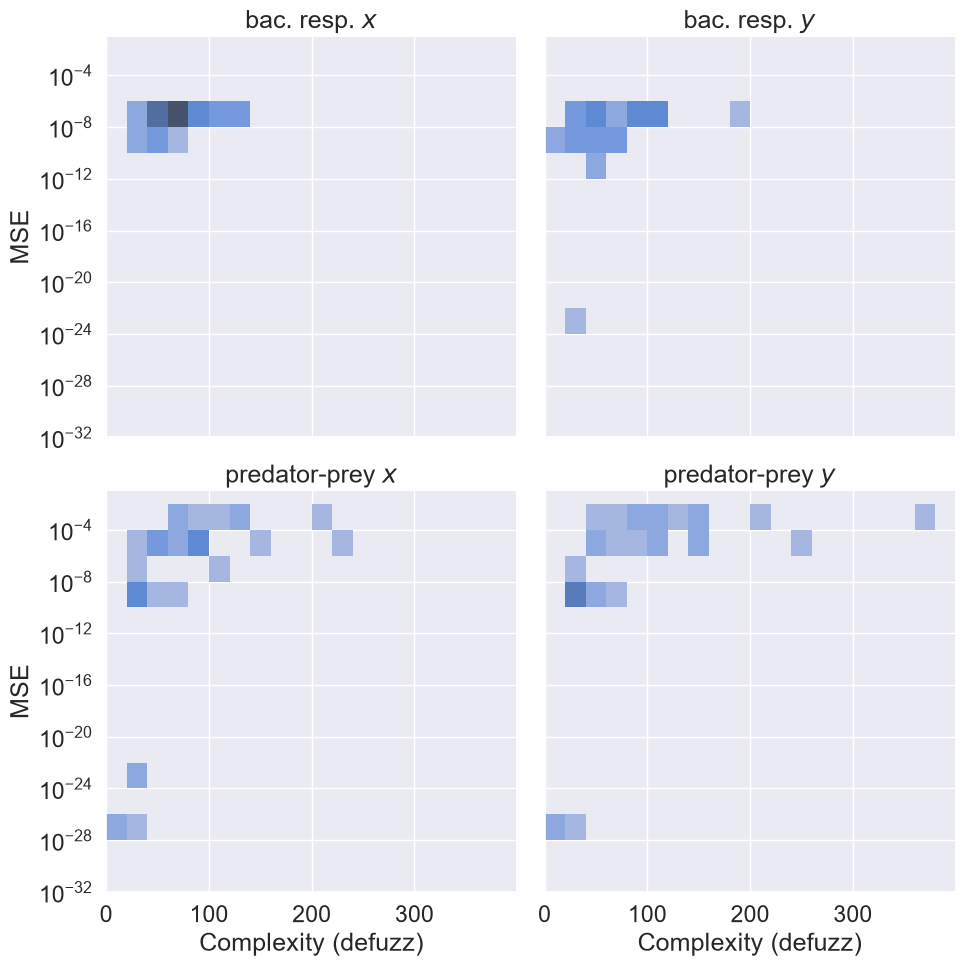

In [73]:
au.complexity_mse_displot(
    srb.loc[data_sets_rational],
    file_stem="srb-rational-complexity-mse-displot",
    **rational_plot_params
    )

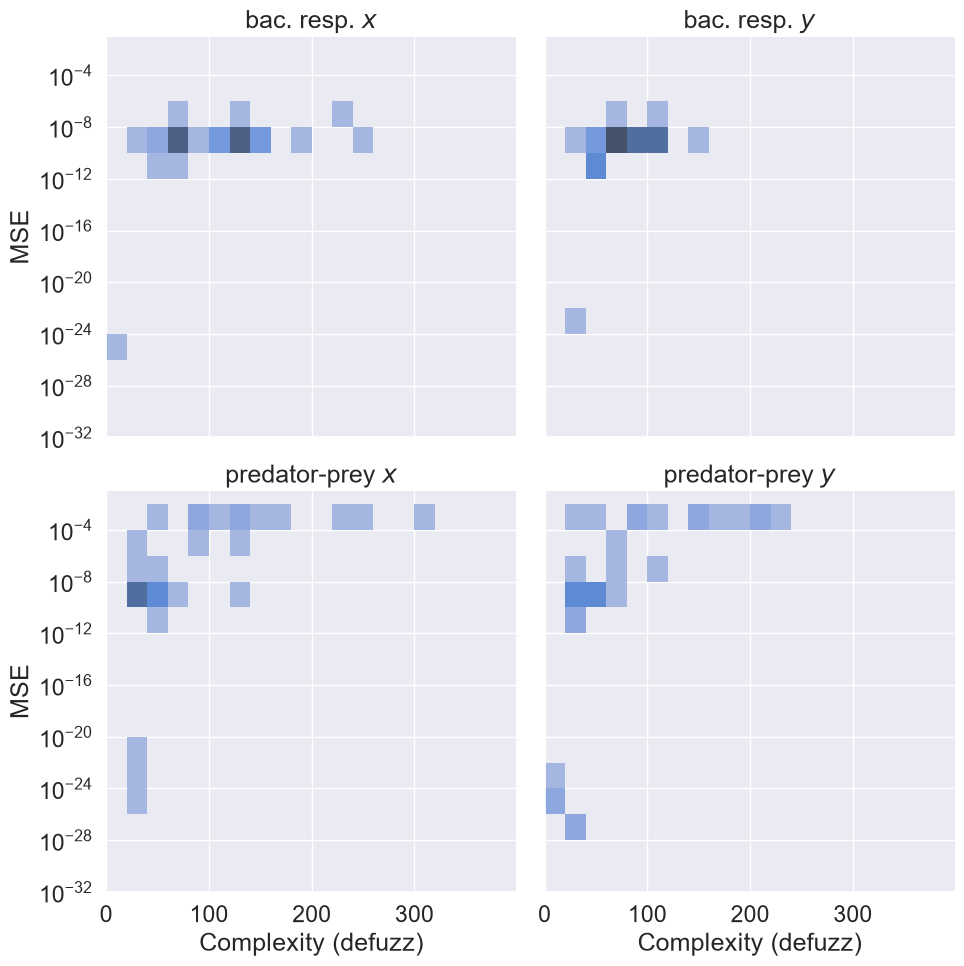

In [74]:
au.complexity_mse_displot(
    cht.loc[data_sets_rational],
    file_stem="cht-rational-complexity-mse-displot",
    **rational_plot_params
    )

## Trigonometric functions, part 1

The shear flow problems are kind of a mess so we'll handle them separately

In [75]:
data_sets_trig = [
    "d_barmag1",
    "d_barmag2",
    "d_glider1",
    "d_glider2",
    ]

These are all correct.

In [76]:
srb.loc[srb_min_mse_ixs].loc[data_sets_trig, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
d_barmag1,22,1.083862e-28,13,-sin(x) + 0.499999999999982*sin(x - y)
d_barmag2,23,7.117569e-29,13,-sin(y) - 0.499999999999968*sin(x - y)
d_glider1,3,2.751114e-28,10,-0.05*x**2 - sin(y)
d_glider2,14,3.850344e-28,9,x - cos(y)/x


In [77]:
srb.loc["d_barmag1", "sympy"].apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-10))

sample_num
22     -sin(x) + 0.4999999999999815*sin(x - y)
23    -sin(x) + 0.49999999999996836*sin(x - y)
28    -sin(x) + 0.49999999999996764*sin(x - y)
12    -sin(x) + 0.49999999999996797*sin(x - y)
16    -sin(x) + 0.49999999999996697*sin(x - y)
21    -sin(x) + 0.49999999999996697*sin(x - y)
24    -sin(x) + 0.49999999999996875*sin(x - y)
1       -sin(x) + 0.499999999999968*sin(x - y)
31     -sin(x) + 0.4999999999999663*sin(x - y)
18     -sin(x) + 0.4999999999999672*sin(x - y)
14    -sin(x) + 0.49999999999996664*sin(x - y)
26    -sin(x) + 0.49999999999996675*sin(x - y)
20     -sin(x) + 0.4999999999999662*sin(x - y)
3     -sin(x) + 0.49999999999996625*sin(x - y)
8      -sin(x) + 0.4999999999999661*sin(x - y)
15     -sin(x) + 0.4999999999999662*sin(x - y)
17     -sin(x) + 0.4999999999999662*sin(x - y)
25     -sin(x) + 0.4999999999999662*sin(x - y)
29     -sin(x) + 0.4999999999999662*sin(x - y)
32     -sin(x) + 0.4999999999999662*sin(x - y)
27    -sin(x) + 0.49999999999996575*sin(x - y)
10

In [78]:
srb.loc["d_barmag2", "sympy"].apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-10))

sample_num
23    -sin(y) - 0.49999999999996825*sin(x - y)
4     -sin(y) - 0.49999999999997385*sin(x - y)
16     -sin(y) - 0.4999999999999727*sin(x - y)
2      -sin(y) - 0.4999999999999727*sin(x - y)
3      -sin(y) - 0.4999999999999728*sin(x - y)
7     -sin(y) - 0.49999999999997297*sin(x - y)
10    -sin(y) - 0.49999999999997297*sin(x - y)
28    -sin(y) - 0.49999999999997297*sin(x - y)
19    -sin(y) - 0.49999999999996986*sin(x - y)
17    -sin(y) - 0.49999999999997186*sin(x - y)
20    -sin(y) - 0.49999999999997186*sin(x - y)
22     -sin(y) - 0.4999999999999716*sin(x - y)
5     -sin(y) - 0.49999999999997163*sin(x - y)
11    -sin(y) - 0.49999999999997163*sin(x - y)
15    -sin(y) - 0.49999999999997163*sin(x - y)
1      -sin(y) - 0.4999999999999719*sin(x - y)
21    -sin(y) - 0.49999999999997174*sin(x - y)
8     -sin(y) - 0.49999999999997247*sin(x - y)
13    -sin(y) - 0.49999999999997247*sin(x - y)
29    -sin(y) - 0.49999999999997247*sin(x - y)
14    -sin(y) - 0.49999999999997247*sin(x - y)
32

In [79]:
srb.loc["d_glider1", "sympy"].apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-10))

sample_num
3      -0.04999999999999999*x**2 - sin(y)
30     -0.04999999999999999*x**2 - sin(y)
2     -0.049999999999999996*x**2 - sin(y)
8      -0.04999999999999999*x**2 - sin(y)
9      -0.04999999999999999*x**2 - sin(y)
19     -0.04999999999999999*x**2 - sin(y)
27    -0.049999999999999975*x**2 - sin(y)
31    -0.049999999999999975*x**2 - sin(y)
6      -0.04999999999999998*x**2 - sin(y)
10     -0.04999999999999998*x**2 - sin(y)
15     -0.04999999999999998*x**2 - sin(y)
18     -0.04999999999999998*x**2 - sin(y)
32     -0.04999999999999998*x**2 - sin(y)
7      -0.04999999999999998*x**2 - sin(y)
16     -0.04999999999999998*x**2 - sin(y)
21     -0.04999999999999998*x**2 - sin(y)
26     -0.04999999999999998*x**2 - sin(y)
12                    -0.05*x**2 - sin(y)
20    -0.049999999999999996*x**2 - sin(y)
28     -0.04999999999999999*x**2 - sin(y)
11     -0.04999999999999999*x**2 - sin(y)
13     -0.04999999999999999*x**2 - sin(y)
4      -0.04999999999999999*x**2 - sin(y)
5      -0.0499999999999

In [80]:
srb.loc["d_glider2", "sympy"].apply(lambda e: au.replace_near_integer(e.evalf(), tolerance=1.0e-10))

sample_num
14    x - cos(y)/x
19    x - cos(y)/x
12    x - cos(y)/x
23    x - cos(y)/x
22    x - cos(y)/x
25    x - cos(y)/x
17    x - cos(y)/x
10    x - cos(y)/x
15    x - cos(y)/x
2     x - cos(y)/x
30    x - cos(y)/x
27    x - cos(y)/x
32    x - cos(y)/x
13    x - cos(y)/x
29    x - cos(y)/x
4     x - cos(y)/x
1     x - cos(y)/x
11    x - cos(y)/x
24    x - cos(y)/x
20    x - cos(y)/x
7     x - cos(y)/x
3     x - cos(y)/x
21    x - cos(y)/x
9     x - cos(y)/x
8     x - cos(y)/x
16    x - cos(y)/x
26    x - cos(y)/x
6     x - cos(y)/x
28    x - cos(y)/x
31    x - cos(y)/x
5     x - cos(y)/x
18    x - cos(y)/x
Name: sympy, dtype: object

All samples are essentially correct.

In [81]:
au.count_by_threshold(srb.loc[data_sets_trig])

data_set
d_barmag1    32
d_barmag2    32
d_glider1    32
d_glider2    32
Name: mse, dtype: int64

In [82]:
trig_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0,29),
    "complexity_binwidth": 1,
    "mse_lims": (5.0e-29, 1.2e-26),
    "mse_binwidth": 0.1,
    "spiffy_titles": [r"bar magnet $x$", r"bar magnet $y$", r"glider $x$", r"glider $y$"],
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

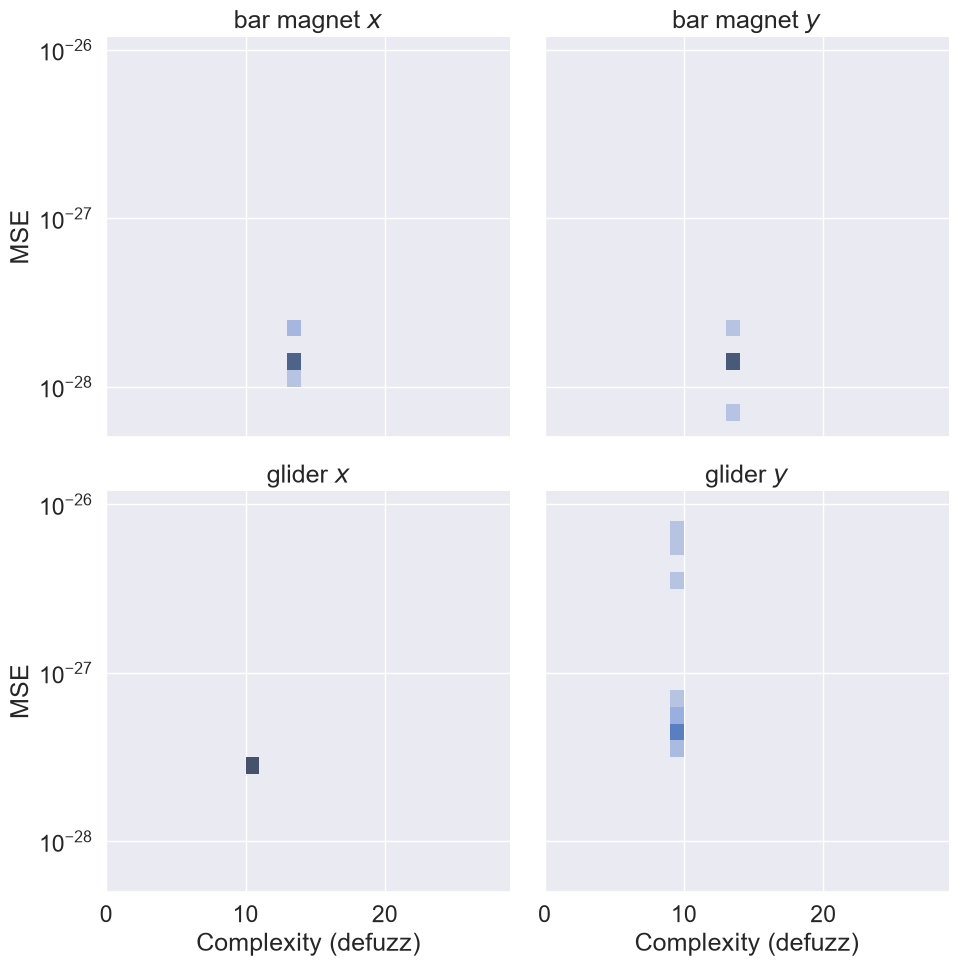

In [83]:
au.complexity_mse_displot(
    srb.loc[data_sets_trig],
    file_stem="srb-trig-complexity-mse-displot",
    **trig_plot_params
    )

## Trigonometric functions, part 2

The shear flow problems are kind of a mess so we'll handle them separately.
I decided not to go into analysis of the `sfgrid` data sets, which I generated by applying the vector field functions to an evenly spaced grid.
They are not part of the original data set.
In some other experiments, the `sfgrid` problem seemed to be easier to solve, but that turned out not to be the case in these benchmarks.

In [84]:
data_sets_sf = [
    "d_shearflow1",
    "d_shearflow2",
    ]

For `shearflow2`, looks like about $17/32$ are correct.
For `shearflow1`, none are correct.

In [85]:
au.count_by_threshold(srb.loc[data_sets_sf],)

data_set
d_shearflow1     0
d_shearflow2    17
Name: mse, dtype: int64

In [86]:
srb.loc["d_shearflow1"].iloc[0]

rating                                                                0.000204
mse                                                                   0.000204
complexity                                                                 135
complexity_defuzz                                                          135
expr                         0.014008471665223458*x2**2*((cos(x1) + 0.37442...
expr_defuzz                  0.0140084716652235*x2**2*((cos(x1) + 0.3744269...
expr_original_syms           0.014008471665223458*y**2*((cos(x) + 0.3744269...
expr_original_syms_defuzz    0.0140084716652235*y**2*((cos(x) + 0.374426941...
sympy                        0.014008471665223458*y**2*((cos(x) + 0.3744269...
sympy_defuzz                 0.0140084716652235*y**2*((cos(x) + 0.374426941...
Name: 12, dtype: object

In [87]:
srb.loc["d_shearflow1", "sympy"].apply(lambda e: au.replace_near_integer(e.evalf(), tolerance=1.0e-10))

sample_num
12    0.0140084716652235*y**2*((cos(x) + 0.374426941...
13    0.170711234184937*y*(cos(x) + 1.09158460071963...
21    -0.628615376378631*y*(exp(cos(x - 0.0088685286...
25    -0.0129646186895955*y**3 + 2.43707688392914e-8...
6     0.00777995598290939*y*(1.57352371723566*y - 1....
9     0.403544059597309*y*(sin(y + cos(x - 0.1340937...
16    0.0125473907789604*y**3 - 0.0371028755407065*y...
14    -0.0312719676666171*y*(-y + 4*sin(y) + 0.40922...
19    0.12416504146211*y**2 + 0.12416504146211*y + (...
4     -1.02435453097262*y*(cos(x + 0.001318433947016...
24    -0.000645050003174855*x - 0.000643079925578576...
29    -0.0315780810153796*x + 0.04822470671572*y*(-0...
18    0.0178021005462331*y**3 + 0.578812261756279*y*...
15    0.0921084200812199*y - 0.0447966709543543*(y -...
3     -0.0135260815439237*x**2 - 0.00073520422644689...
28    -0.000258361024886757*x**2*(x + 2*y + (-2*y + ...
7     0.262586992642326*y**2 - 0.0525168938245052*y ...
26    -0.037465650980109*y**2 - 0.079

In [88]:
srb.loc["d_shearflow2", "sympy"].apply(lambda e: au.replace_near_integer(e.evalf(), tolerance=1.0e-10))

sample_num
2     0.549999999999995*sin(x) + 0.224999999999996*s...
5     0.549999999999989*sin(x) + 0.224999999999998*s...
26    0.549999999999986*sin(x) + 0.224999999999994*s...
1     0.449999999999982*sin(x)*cos(2*y) + 0.54999999...
20    0.449999999999992*sin(x)*cos(2*y) + 0.54999999...
12    0.449999999999976*sin(x)*cos(2*y) + 0.54999999...
4     0.89999999999991*sin(x)*cos(y)**2 + 0.10000000...
8     0.449999999999959*sin(x)*cos(2*y) + 0.54999999...
14    -(0.899999999999893*sin(y)**2 + 0.899999999999...
6     (0.449999999999948*sin(x) + 0.899999999999895)...
15    0.549999999999968*sin(x) + 0.225000000000008*s...
11    0.549999999998883*sin(x) + 0.224999999999991*s...
22         -0.899999999999563*sin(x)*sin(y)**2 + sin(x)
28         -0.899999999999833*sin(x)*sin(y)**2 + sin(x)
7          -0.899999999999702*sin(x)*sin(y)**2 + sin(x)
13         -0.899999999998668*sin(x)*sin(y)**2 + sin(x)
9     0.549999999999708*sin(x) + 0.224999999999951*s...
24    -(7.23493681257308e-6*y - 5.090

In [89]:
shearflow_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 299),
    "complexity_binwidth": 10,
    "mse_lims": (1.0e-31, 1.e-1),
    "mse_binwidth": 1.0,
    "spiffy_titles": [r"shear flow $x$", r"shear flow $y$"],
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

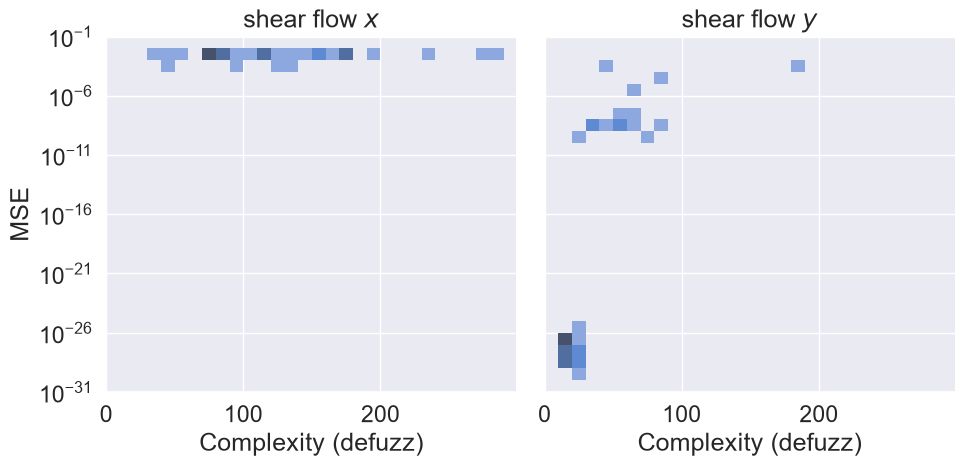

In [90]:
au.complexity_mse_displot(
    srb.loc[data_sets_sf],
    file_stem="srb-shearflow-complexity-mse-displot",
    **shearflow_plot_params
    )

If we cheat, there are a lot more correct answers.
The CHT configuration includes a full set of trig functions, including $\cot$, which saves Jessamine from having to build up $\cos / \sin$.

In [91]:
cht.loc["d_shearflow1", "sympy"].apply(lambda e: au.replace_near_integer(sympy.expand(e.evalf()), tolerance=1.0e-10))

sample_num
7                                         cos(x)*cot(y)
30                                        cos(x)*cot(y)
8                                         cos(x)*cot(y)
21                                        cos(x)*cot(y)
26                                        cos(x)*cot(y)
25                                        cos(x)*cot(y)
19                                        cos(x)*cot(y)
10                                        cos(x)*cot(y)
12                                        cos(x)*cot(y)
16                                        cos(x)*cot(y)
23                                        cos(x)*cot(y)
32                                        cos(x)*cot(y)
9                                         cos(x)*cot(y)
22                                        cos(x)*cot(y)
18                                        cos(x)*cot(y)
31                                        cos(x)*cot(y)
27                                        cos(x)*cot(y)
14                                   

In [92]:
cht.loc["d_shearflow2", "sympy"].apply(lambda e: au.replace_near_integer(sympy.expand(e.evalf()), tolerance=1.0e-10))

sample_num
14    0.449999999999997*sin(x)*cos(2*y) + 0.54999999...
9     0.549999999999994*sin(x) + 0.224999999999997*s...
18    0.449999999999989*sin(x)*cos(2*y) + 0.54999999...
27    0.549999999999987*sin(x) + 0.224999999999993*s...
4     0.549999999999986*sin(x) + 0.224999999999992*s...
32    0.549999999999985*sin(x) + 0.224999999999993*s...
8     0.449999999999982*sin(x)*cos(2*y) + 0.54999999...
24    0.449999999999979*sin(x)*cos(2*y) + 0.54999999...
19    0.549999999999972*sin(x) + 0.224999999999983*s...
3     0.44999999999997*sin(x)*cos(2*y) + 0.549999999...
28         -0.899999999999932*sin(x)*sin(y)**2 + sin(x)
26    0.899999999999903*sin(x)*cos(y)**2 + 0.1000000...
5          -0.899999999999867*sin(x)*sin(y)**2 + sin(x)
23         -0.899999999999848*sin(x)*sin(y)**2 + sin(x)
11         -0.899999999999827*sin(x)*sin(y)**2 + sin(x)
2     0.549999999999882*sin(x) + 0.225000000000011*s...
15    0.899999999999845*sin(x)*cos(y)**2 + 0.1000000...
21    0.899999999991451*sin(x)*cos(y)

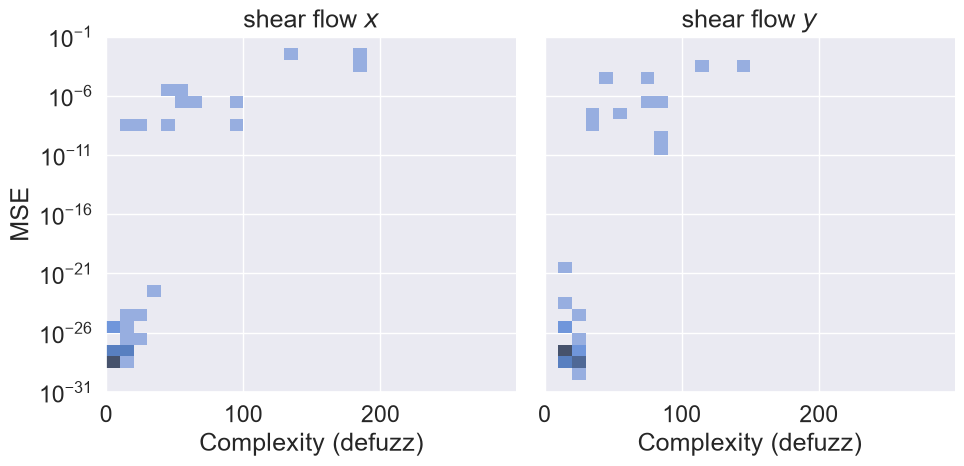

In [93]:
au.complexity_mse_displot(
    cht.loc[data_sets_sf],
    file_stem="cht-shearflow-complexity-mse-displot",
    **shearflow_plot_params
    )

In [94]:
au.count_by_threshold(cht.loc[data_sets_sf],)

data_set
d_shearflow1    20
d_shearflow2    21
Name: mse, dtype: int64

Using the SRB configuration and running up to 192 trials, `shearflow1` still doesn't get solved.

In [95]:
srb_extra.loc[([srb_key, srb_extra_key], ["d_shearflow1"]), :].sort_values("mse")

rating       mse  complexity  \
run_set             data_set     sample_num                                   
SRB-2026-07-25-1900 d_shearflow1 69          0.000072  0.000072         123   
                                 47          0.000103  0.000103         119   
                                 145         0.000156  0.000156          87   
SRB-2026-07-13-1130 d_shearflow1 12          0.000204  0.000204         135   
SRB-2026-07-25-1900 d_shearflow1 12          0.000204  0.000204         135   
...                                               ...       ...         ...   
                                 137         0.004895  0.004895         242   
                                 57          0.005015  0.005015         126   
                                 45          0.005027  0.005027         203   
SRB-2026-07-13-1130 d_shearflow1 30          0.005549  0.005549         693   
SRB-2026-07-25-1900 d_shearflow1 30          0.005549  0.005549         693   

                                             complexity_defuzz  \
run_set             data_set     sample_num                      
SRB-2026-07-25-1900 d_shearflow1 69                        123   
                                 47                        119   
                                 145                        87   
SRB-2026-07-13-1130 d_shearflow1 12                        135   
SRB-2026-07-25-1900 d_shearflow1 12                        135   
...                                                        ...   
                                 137                        58   
                                 57                        108   
                                 45                        136   
SRB-2026-07-13-1130 d_shearflow1 30                         77   
SRB-2026-07-25-1900 d_shearflow1 30                         77   

                                                                                          expr  \
run_set             data_set     sample_num                                                      
SRB-2026-07-25-1900 d_shearflow1 69          -0.118104188172102*x2**2*(x2 + 0.0223590303558...   
                                 47          -0.4647155002583312*x2*cos(x1) - 0.00277413974...   
                                 145         0.014415368220516154*x2 + 0.011048903354395965...   
SRB-2026-07-13-1130 d_shearflow1 12          0.014008471665223458*x2**2*((cos(x1) + 0.37442...   
SRB-2026-07-25-1900 d_shearflow1 12          0.014008471665223458*x2**2*((cos(x1) + 0.37442...   
...                                                                                        ...   
                                 137         0.051382259509387053*x2**3 - 0.162912188903124...   
                                 57          0.02735149859036374*x1 + 0.0048108472271694*x2...   
                                 45          0.01539974441948893*x1**2 - 0.0038511728143761...   
SRB-2026-07-13-1130 d_shearflow1 30          0.031681196444548878*x1 - 0.023842005978581191...   
SRB-2026-07-25-1900 d_shearflow1 30          0.031681196444548878*x1 - 0.023842005978581191...   

                                                                                   expr_defuzz  \
run_set             data_set     sample_num                                                      
SRB-2026-07-25-1900 d_shearflow1 69          -0.118104188172102*x2**2*(x2 + 0.0223590303558...   
                                 47          -0.464715500258331*x2*cos(x1) - 0.002774139746...   
                                 145         0.0144153682205162*x2 + 0.011048903354396*(-8*...   
SRB-2026-07-13-1130 d_shearflow1 12          0.0140084716652235*x2**2*((cos(x1) + 0.3744269...   
SRB-2026-07-25-1900 d_shearflow1 12          0.0140084716652235*x2**2*((cos(x1) + 0.3744269...   
...                                                                                        ...   
                                 137         0.0513822595093871*x2**3 - 0.162912188903125*x...   
   

In [96]:
shearflow1_best = srb_extra.loc[([srb_key, srb_extra_key], ["d_shearflow1"]), :].sort_values("mse").iloc[0]

In [97]:
shearflow1_best

rating                                                                0.000072
mse                                                                   0.000072
complexity                                                                 123
complexity_defuzz                                                          123
expr                         -0.118104188172102*x2**2*(x2 + 0.0223590303558...
expr_defuzz                  -0.118104188172102*x2**2*(x2 + 0.0223590303558...
expr_original_syms           -0.118104188172102*y**2*(y + 0.022359030355816...
expr_original_syms_defuzz    -0.118104188172102*y**2*(y + 0.022359030355816...
sympy                        -0.118104188172102*y**2*(y + 0.022359030355816...
sympy_defuzz                 -0.118104188172102*y**2*(y + 0.022359030355816...
Name: (SRB-2026-07-25-1900, d_shearflow1, 69), dtype: object

In [98]:
au.replace_near_integer(shearflow1_best.sympy, tolerance=1.0e-2)

-0.118104188172102*y**2*(y + 0.022359030355816656)*cos(x) - 0.13815385894148047*y*(y + 0.022359030355816656)*(cos(x) + 0.1910428876395267 + cos(x)/y) - 0.03453788677903223*y - 0.04085942181262791*sin(y - sin(-y + cos(0.9723342801300402/y) + 0.9552819392883667) + 1.172849630164276) + 0.2430339429007046*cos(x) - 0.06358757816721171*cos(0.9723342801300402/y) + 0.13880144474934365 + 0.9113742329723371*cos(x)/y + 0.13506487261563469/y